In [1]:
!pip install gradio
from fastai.vision.all import *
import gradio as gr
import timm

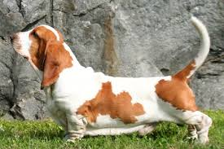

In [2]:
im=PILImage.create('basset.jpg')
im.thumbnail((224,224))
im

In [3]:
learn=load_learner('model.pkl')

/home/a-kuumar/Desktop/Achyut/coding_mat/ml-journey/env/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [4]:
learn.predict(im)

[W527 20:36:43.919525632 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W527 20:36:43.939363347 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


('basset_hound',
 tensor(14),
 tensor([3.2155e-07, 1.5728e-05, 2.3085e-05, 1.1562e-06, 6.0121e-08, 1.0618e-06,
         1.2560e-06, 2.6797e-06, 4.8755e-08, 1.0107e-07, 5.0593e-07, 5.8090e-08,
         1.1530e-06, 1.6072e-07, 9.9943e-01, 5.0127e-04, 2.4274e-06, 3.7642e-08,
         6.0752e-08, 3.6052e-06, 3.1033e-07, 1.8429e-07, 3.9594e-07, 1.6667e-07,
         5.3105e-06, 2.3485e-07, 1.5335e-06, 2.2009e-06, 1.6060e-08, 8.6415e-08,
         8.7933e-07, 2.9137e-07, 4.6977e-07, 1.4245e-07, 2.6442e-07, 1.3010e-07,
         3.3015e-07]))

In [5]:
categories=learn.dls.vocab
def classify_image(img):
    pred,idx,probs=learn.predict(img)
    return dict(zip(categories,map(float,probs)))

In [6]:
classify_image(im)

[W527 20:36:43.342091592 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W527 20:36:43.354460085 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


{'Abyssinian': 3.215502886178001e-07,
 'Bengal': 1.5727675418020226e-05,
 'Birman': 2.308546936546918e-05,
 'Bombay': 1.1562489135030773e-06,
 'British_Shorthair': 6.012076170236469e-08,
 'Egyptian_Mau': 1.061786747413862e-06,
 'Maine_Coon': 1.256017071682436e-06,
 'Persian': 2.6796969905262813e-06,
 'Ragdoll': 4.87551083949711e-08,
 'Russian_Blue': 1.0106716530344784e-07,
 'Siamese': 5.059280283603584e-07,
 'Sphynx': 5.809004477441704e-08,
 'american_bulldog': 1.1530335086717969e-06,
 'american_pit_bull_terrier': 1.607221804533765e-07,
 'basset_hound': 0.9994322657585144,
 'beagle': 0.0005012716283090413,
 'boxer': 2.4274102088384097e-06,
 'chihuahua': 3.764191447430676e-08,
 'english_cocker_spaniel': 6.075198655253189e-08,
 'english_setter': 3.605238816817291e-06,
 'german_shorthaired': 3.1032558922561293e-07,
 'great_pyrenees': 1.8429032877520513e-07,
 'havanese': 3.9593817291461164e-07,
 'japanese_chin': 1.6666862734382448e-07,
 'keeshond': 5.310482720233267e-06,
 'leonberger': 2.3

In [7]:
image=gr.Image(width=192,height=192)
label=gr.Label()
examples=['basset.jpg']

In [8]:
intf=gr.Interface(fn=classify_image,inputs=image,outputs=label,examples=examples)
intf.launch(inline=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [9]:
m=learn.model
m

Sequential(
  (0): TimmBody(
    (model): ConvNeXt(
      (stem): Sequential(
        (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True, bias=True)
      )
      (stages): Sequential(
        (0): ConvNeXtStage(
          (downsample): Identity()
          (blocks): Sequential(
            (0): ConvNeXtBlock(
              (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
              (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True, bias=True)
              (mlp): Mlp(
                (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
                (act): GELU()
                (drop1): Dropout(p=0.0, inplace=False)
                (norm): Identity()
                (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
                (drop2): Dropout(p=0.0, inplace=False)
              )
              (shortcut): Identity()
              (drop_path):

In [10]:
l=m.get_submodule('0.model.stem.1')
list(l.parameters())

[Parameter containing:
 tensor([ 1.0133,  0.1964,  0.2839,  0.4785,  0.3738,  0.6010,  0.7709,  0.8900,
          0.7743,  0.2103,  0.3977, -0.0024,  0.3673,  0.2322,  0.2691,  0.2243,
          0.8016,  0.4737,  1.7087,  0.2959,  0.2102,  0.4276,  0.0030,  0.6764,
          0.7598,  0.6412,  0.4666,  1.1119,  0.8561,  0.3586,  0.5594,  0.2450,
          0.4621,  0.5283,  0.3078,  0.3771,  0.2466,  0.5407,  0.4951,  0.3024],
        requires_grad=True),
 Parameter containing:
 tensor([-1.7864e-01,  2.3480e-02, -1.9901e-02,  3.5764e-02, -6.2487e-03,
         -1.4791e-03, -1.7768e-02, -1.9287e-01,  5.7884e-03, -5.4211e-01,
          8.7427e-01, -1.5395e-02, -4.5288e-02, -7.8052e-04,  1.8082e-01,
          6.4362e-03,  7.0764e-04,  2.0329e-02, -4.7275e-02, -2.9533e-02,
          5.1871e-03,  3.0556e-02, -7.4492e-04, -8.5087e-03, -5.9441e-03,
         -3.9996e-04,  1.1600e-01,  2.9368e-03, -9.3245e-01, -2.6183e-02,
          2.3112e-03, -1.6605e-02,  2.9151e-02, -7.8993e-03,  1.1442e-02,
 

In [11]:
l=m.get_submodule('0.model.stages.0.blocks.1.mlp.fc1')
list(l.parameters())

[Parameter containing:
 tensor([[[[ 0.0562]],
 
          [[-0.0129]],
 
          [[-0.0960]],
 
          ...,
 
          [[-0.0938]],
 
          [[ 0.0245]],
 
          [[ 0.0328]]],
 
 
         [[[-0.0107]],
 
          [[ 0.1269]],
 
          [[-0.0082]],
 
          ...,
 
          [[ 0.0756]],
 
          [[-0.0023]],
 
          [[ 0.0012]]],
 
 
         [[[-0.0033]],
 
          [[ 0.0048]],
 
          [[-0.0065]],
 
          ...,
 
          [[-0.0290]],
 
          [[ 0.0170]],
 
          [[-0.0124]]],
 
 
         ...,
 
 
         [[[ 0.0166]],
 
          [[ 0.0062]],
 
          [[-0.0598]],
 
          ...,
 
          [[ 0.0805]],
 
          [[-0.1274]],
 
          [[-0.0336]]],
 
 
         [[[ 0.0057]],
 
          [[ 0.0393]],
 
          [[-0.0036]],
 
          ...,
 
          [[-0.0273]],
 
          [[-0.2681]],
 
          [[ 0.0232]]],
 
 
         [[[ 0.0027]],
 
          [[-0.0225]],
 
          [[ 0.0035]],
 
          ...,
 
          [[-0.04